# Índice de calor en Iquitos (2000–2024)
## Notebook 03 · Visualización, conclusiones e implicaciones

**Entrada:** `data/processed/iquitos_indice_calor.csv`, generado en `02_analisis.ipynb` (197,457 horas con temperatura, punto de rocío, humedad relativa e índice de calor).

**Contenido**
1. El día típico en Iquitos
2. Índice de calor por mes y hora
3. Horas de precaución extrema y peligro por mes
4. Conclusiones e implicaciones

**Resultado:** gráficos en `images/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/iquitos_indice_calor.csv", parse_dates=["fecha_hora"])
df.head()

,fecha_hora,temperatura,punto_rocio,anio,mes,hora,humedad_relativa,indice_calor
0,2000-01-01 00:00:00-05:00,25.0,24.0,2000,1,0,94.191012,26.014988
1,2000-01-01 01:00:00-05:00,25.0,23.6,2000,1,1,91.951467,25.956511
2,2000-01-01 02:00:00-05:00,25.0,24.0,2000,1,2,94.191012,26.014988
3,2000-01-01 03:00:00-05:00,24.0,23.0,2000,1,3,94.148645,24.913881
4,2000-01-01 04:00:00-05:00,23.0,23.0,2000,1,4,100.000000,23.966667


---
## 1. El día típico en Iquitos

Promedio de la temperatura y del índice de calor para cada hora del día, considerando los 23 años analizados.

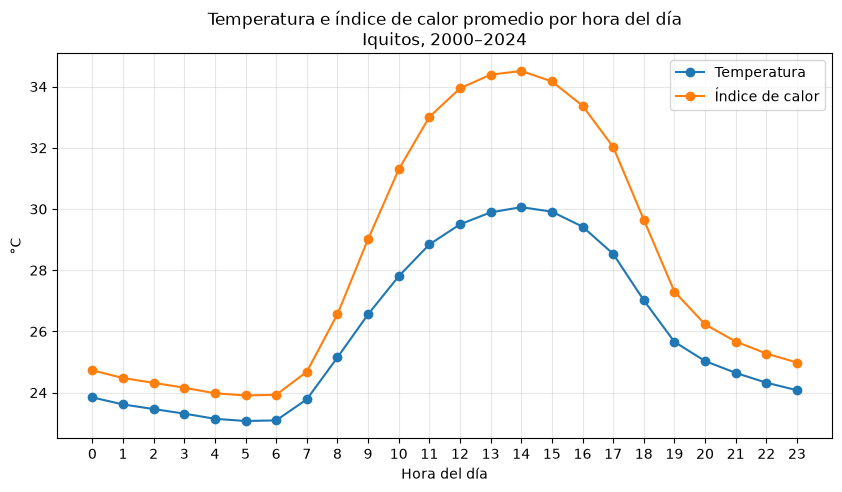

In [2]:
import matplotlib.pyplot as plt

# Promedio de cada variable para cada hora del día
perfil = df.groupby("hora")[["temperatura", "indice_calor"]].mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(perfil.index, perfil["temperatura"], marker="o", label="Temperatura")
ax.plot(perfil.index, perfil["indice_calor"], marker="o", label="Índice de calor")

ax.set_title("Temperatura e índice de calor promedio por hora del día\nIquitos, 2000–2024")
ax.set_xlabel("Hora del día")
ax.set_ylabel("°C")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(alpha=0.3)

plt.savefig("../images/perfil_horario.png", dpi=150, bbox_inches="tight")
plt.show()

- El calor es mas intenso a las 14:00 horas del dia
- La mayor diferencia entre la Temperatura y el Índice de calor es a las 14:00, con una diferencia de 4 C°
- No hay una hora donde las dos linea se toquen, cuando es muy seco deberia estar juntas

In [19]:
# Hora del índice de calor máximo
print("Índice de calor máximo:", perfil["indice_calor"].idxmax(), "h →", round(perfil["indice_calor"].max(), 1), "°C")

# Hora de mayor diferencia entre índice de calor y temperatura
diferencia = perfil["indice_calor"] - perfil["temperatura"]
print("Mayor diferencia:", diferencia.idxmax(), "h →", round(diferencia.max(), 2), "°C")
print("Menor diferencia:", diferencia.idxmin(), "h →", round(diferencia.min(), 2), "°C")

Índice de calor máximo: 14 h → 34.5 °C
Mayor diferencia: 13 h → 4.5 °C
Menor diferencia: 4 h → 0.83 °C


In [20]:
df.groupby("hora")["humedad_relativa"].mean().round(1)

hora
0     93.1
1     93.5
2     93.9
3     94.2
4     94.3
5     94.6
6     94.6
7     93.3
8     88.7
9     83.1
10    78.2
11    74.2
12    71.4
13    69.5
14    68.6
15    68.8
16    70.5
17    74.1
18    80.7
19    86.4
20    89.2
21    90.7
22    91.7
23    92.5
Name: humedad_relativa, dtype: float64

---
## 2. Índice de calor por mes y hora

`pivot_table` reorganiza los datos en una tabla de 12 meses por 24 horas, con el índice de calor promedio en cada celda. Es el equivalente a una tabla dinámica de Excel o una matriz de Power BI.

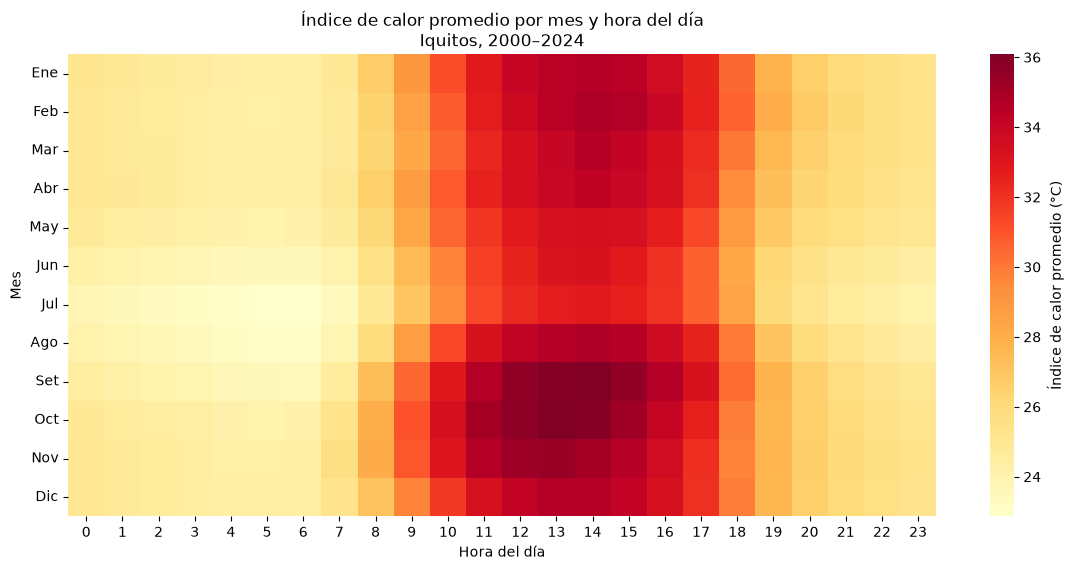

In [21]:
import seaborn as sns

meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Set", "Oct", "Nov", "Dic"]

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(tabla, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Índice de calor promedio (°C)"})

ax.set_title("Índice de calor promedio por mes y hora del día\nIquitos, 2000–2024")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Mes")
ax.set_yticklabels(meses, rotation=0)

plt.savefig("../images/heatmap_indice_calor.png", dpi=150, bbox_inches="tight")
plt.show()

- La zona de mayor intensidad está entre las **12:00 y las 15:00**, de **setiembre a noviembre**, con octubre como el mes más crítico.
- De **diciembre a mayo** el calor de la tarde sigue siendo alto, aunque menor que en el pico.
- **Junio y julio** son los meses más frescos, especialmente de madrugada. Coincide con la temporada de friajes, las masas de aire frío que llegan desde el sur.
- En resumen: el calor intenso no se concentra en unos pocos meses, sino que está presente casi todo el año, con un pico a fin de año y un respiro a mitad de año.

---
## 3. Horas de precaución extrema por mes

Se usan las categorías del Servicio Meteorológico Nacional de EE. UU. (NWS):

| Índice de calor | Categoría |
|---|---|
| 27 a 32 °C | Precaución |
| 32 a 41 °C | Precaución extrema |
| 41 a 54 °C | Peligro |

Se calcula el porcentaje de horas de cada mes con índice de calor de 32 °C o más, y se convierte a horas por día. Se usan porcentajes y no totales para que los meses sean comparables, sin importar cuántos días o datos tengan.

In [8]:
df["precaucion_extrema"] = df["indice_calor"] >= 32

# Porcentaje de horas de cada mes en precaución extrema
pct_mes = df.groupby("mes")["precaucion_extrema"].mean() * 100

# Convertido a horas por día
horas_dia = (pct_mes * 24 / 100).round(1)
horas_dia

mes
1     5.8
2     5.9
3     5.5
4     5.4
5     4.8
6     4.4
7     4.5
8     6.1
9     6.9
10    6.8
11    6.4
12    5.9
Name: precaucion_extrema, dtype: float64

In [10]:
df["precaucion_extrema"] = df["indice_calor"] >= 32
pct_mes = df.groupby("mes")["precaucion_extrema"].mean() * 100
horas_dia = (pct_mes * 24 / 100).round(1)
horas_dia

mes
1     5.8
2     5.9
3     5.5
4     5.4
5     4.8
6     4.4
7     4.5
8     6.1
9     6.9
10    6.8
11    6.4
12    5.9
Name: precaucion_extrema, dtype: float64

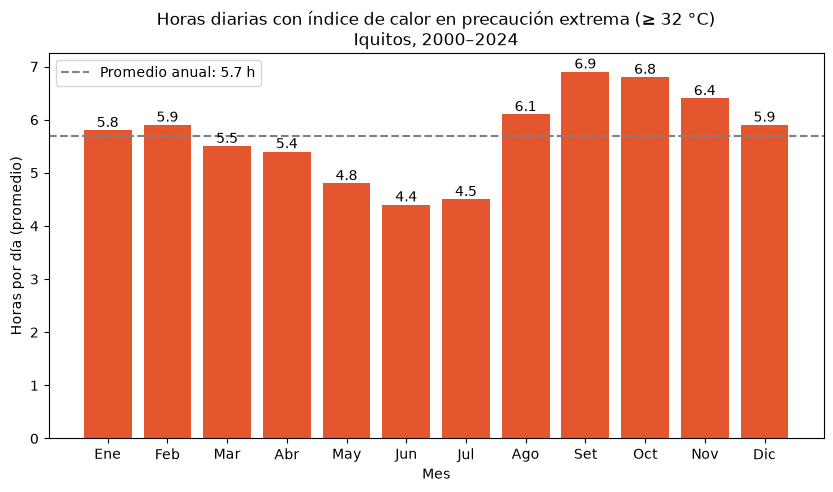

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

# Barras con su valor encima
barras = ax.bar(horas_dia.index, horas_dia.values, color="#E4572E")
ax.bar_label(barras, fmt="%.1f")

# Título y ejes
ax.set_title("Horas diarias con índice de calor en precaución extrema (≥ 32 °C)\nIquitos, 2000–2024")
ax.set_xlabel("Mes")
ax.set_ylabel("Horas por día (promedio)")

# Nombres de los meses
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Set", "Oct", "Nov", "Dic"]
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)

# Línea del promedio anual
promedio = horas_dia.mean()
ax.axhline(promedio, color="gray", linestyle="--", label=f"Promedio anual: {promedio:.1f} h")
ax.legend()

plt.savefig("../images/horas_calor_extremo.png", dpi=150, bbox_inches="tight")
plt.show()

- **Setiembre (6.9 h/día) y octubre (6.8 h/día)** son los meses con más horas de precaución extrema, seguidos de noviembre (6.4 h/día).
- **Junio (4.4 h/día) y julio (4.5 h/día)** son los meses con menos horas.
- Incluso en el mes más fresco hay más de 4 horas diarias de precaución extrema en promedio.
- **Agosto (6.1 h/día)** marca el inicio del alza: es el primer mes que supera claramente el promedio anual de 5.7 h/día.

### 3.1 Horas en categoría de peligro (≥ 41 °C)

In [22]:
df["peligro"] = df["indice_calor"] >= 41

print(df["peligro"].sum(), "horas en categoría de peligro")
print(round(df["peligro"].mean() * 100, 2), "% del total")

# Horas de peligro por mes
df.groupby("mes")["peligro"].sum()

1543 horas en categoría de peligro
0.78 % del total


mes
1     159
2      82
3      93
4      81
5      46
6      21
7      14
8     138
9     277
10    310
11    254
12     68
Name: peligro, dtype: int64

---
## 4. Conclusiones y recomendaciones

**Conclusiones**

1. En Iquitos, el calor intenso está presente casi todo el año: incluso en el mes más fresco hay más de 4 horas diarias de precaución extrema.
2. El pico ocurre de **setiembre a noviembre**, entre las **12:00 y las 15:00**.
3. **Junio y julio** son la única temporada claramente más fresca.
4. La humedad eleva la sensación térmica hasta **4.5 °C** por encima de la temperatura en las horas centrales del día.

**Recomendaciones para un negocio de climatización**

1. **Prepararse para la mayor demanda de setiembre a noviembre**, cuando se esperan más instalaciones y reparaciones por el uso intensivo de los equipos.
2. **Concentrar las campañas de mantenimiento preventivo en junio y julio**, la temporada de menor calor, con la meta de terminar antes de agosto.
3. **Asegurar el stock de equipos antes de agosto**, cuando empieza el alza. Como la mercadería llega a Iquitos por vía fluvial o aérea, los pedidos deberían hacerse con la anticipación suficiente según el tiempo de llegada de cada proveedor.
